# DLR-TomoSAR — Dataset-Creation Walkthrough

**Goal.** Step through every transformation performed by `dataset_creation.pipeline.DatasetCreationPipeline` and validate it visually and quantitatively on an existing pre-processed run.

The pipeline (see `dataset_creation/pipeline.py`) chains together:

| Stage | Component                            | Responsibility                                                                  |
|------:|--------------------------------------|---------------------------------------------------------------------------------|
| 1     | `DatasetLayout` (`crop.py`)          | Parses `dataset.json`, resolves artifacts, exposes the global crop.             |
| 2     | `Cropper` (`crop.py`)                | Translates `SplitRegions` (global → local), memory-maps and slices arrays.      |
| 3     | `compute_patch_grid_info` (`patch.py`) | Solves the (n_v, n_h, padding) tiling for one split's spatial size.            |
| 4     | `extract_patch` (`patch.py`)         | Cuts an individual patch with optional reflective padding.                      |
| 5     | `Representation.convert` (`dataset_config.py`) | Maps complex `(P, h, w)` → real `(P·cpp, h, w)`.                       |
| 6     | `PassDropConfig` + `TomoPatchDataset.__getitem__` (`load.py`) | Optional pass dropout; per-item tensor assembly. |
| 7     | `LoaderBuilder.build` (`load.py`)    | Wraps datasets into `DataLoader`s.                                              |
| 8     | `DatasetMetadataWriter` (`metadata.py`) | Persists config / crop / patch JSONs into the training run directory.        |

**Mode.** Read-only on the workspace: we point at a finished pre-processing run and exercise every transformation in-process. The metadata writer's output goes to a temporary directory.

**Sample run.** `Dataset/run_1000a1100a500a600_…` — global crop `(1000, 1100, 500, 600)` ⇒ Az=100, Rg=100, P=4, N_gauss=3.

## §0 — Setup, helpers, reproducibility

In [ ]:
from configuration.preprocessing_config import CropRegion

Imports OK. NumPy 2.4.4 | torch 2.11.0+cu130


In [2]:
def describe_array(name, arr):
    a = np.asarray(arr)
    if np.iscomplexobj(a):
        m = np.abs(a)
        s = dict(shape=a.shape, dtype=str(a.dtype),
                 mag_min=float(np.nanmin(m)), mag_max=float(np.nanmax(m)),
                 mag_mean=float(np.nanmean(m)))
    else:
        s = dict(shape=a.shape, dtype=str(a.dtype),
                 min=float(np.nanmin(a)), max=float(np.nanmax(a)),
                 mean=float(np.nanmean(a)), std=float(np.nanstd(a)))
    print(f'[{name}]')
    for k, v in s.items():
        print(f'    {k:<8} = {v}')
    return s


def imshow_with_stats(ax, data, *, title='', cmap=None, vmin=None, vmax=None,
                      origin='lower', aspect='auto', colorbar=True, label=''):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, origin=origin, aspect=aspect)
    ax.set_title(title)
    if colorbar:
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if label:
            cb.set_label(label)
    return im


def assert_shape(name, arr, expected):
    got  = tuple(arr.shape)
    ok   = got == tuple(expected)
    flag = '\u2713' if ok else '\u2717'
    print(f'  {flag}  {name:<28} shape={got}   expected={tuple(expected)}')
    assert ok, f'Shape mismatch for {name}'


class SilentLogger:
    """Drop-in replacement for `training.logger.Logger` that prints nothing."""
    def section   (self, *_a, **_k): pass
    def subsection(self, *_a, **_k): pass
    def info      (self, *_a, **_k): pass
    def warning   (self, *_a, **_k): pass
    def error     (self, *_a, **_k): pass
    def debug     (self, *_a, **_k): pass

print('Helpers ready.')

Helpers ready.


## §1 — Stage 1: `DatasetLayout`

Parses `dataset.json` from the pre-processing run and exposes:
- `global_crop` — the `CropRegion` used at pre-processing time,
- `tomogram_tag` / `parameter_tag` — tag strings that name every artifact,
- `artifact_path(key)` — resolves any of `{inputs, parameters, tomogram, full_tomogram, input_tomogram, full_parameters}`.

In [3]:
PREPROC_RUN = Path('/ste/rnd/User/vice_vi/Dataset/new_good')
assert (PREPROC_RUN / 'data' / 'dataset.json').exists(), f'Missing dataset.json under {PREPROC_RUN}'

logger = SilentLogger()
layout = DatasetLayout(PREPROC_RUN, logger=logger)

print(f'Run directory   : {layout.run_directory}')
print(f'Global crop     : {layout.global_crop.as_tuple()}')
print(f'                  Az={layout.global_crop.azimuth_size}, Rg={layout.global_crop.range_size}')
print(f'dataset_type    : {layout.dataset_type}')
print(f'tomogram_tag    : {layout.tomogram_tag}')
print(f'parameter_tag   : {layout.parameter_tag}')
print('\nResolved artifact paths:')
for key in ('inputs', 'parameters', 'tomogram'):
    p = layout.artifact_path(key)
    assert p.exists(), f'Missing artifact: {p}'
    print(f'  {key:<10} -> {p.name}    ({p.stat().st_size / 1e6:6.2f} MB)')

Run directory   : /ste/rnd/User/vice_vi/Dataset/new_good
Global crop     : (1000, 16000, 500, 4000)
                  Az=15000, Rg=3500
dataset_type    : FSAR
tomogram_tag    : 1000a16000a500a4000_dtmf_Xtomo_id2X
parameter_tag   : 1000a16000a500a4000_1_Xparams_id2X

Resolved artifact paths:
  inputs     -> inputs_1000a16000a500a4000_dtmf_Xtomo_id2X.npy    (1680.00 MB)
  parameters -> parameters_1000a16000a500a4000_1_Xparams_id2X.npy    (2520.00 MB)
  tomogram   -> tomogram_1000a16000a500a4000_1_Xparams_id2X.npy    (63000.00 MB)


## §2 — Stage 2: `SplitRegions` and `Cropper`

`SplitRegions` partitions the **global crop** into three contiguous azimuth bands `train / val / test` (range axis is shared in this codebase). `Cropper.to_local_slices` translates a global `CropRegion` into NumPy slices into the memory-mapped artifacts; `Cropper.load_split` returns a dict `{inputs, parameters, tomogram}` of views.

We use `SplitRegions.from_ratios` here because the sample crop is only Az=100 wide (the production training script in `main/train.py` uses `'manual'` mode with explicit azimuth ranges instead).

In [4]:
splits = SplitRegions.from_ratios(
    global_crop = layout.global_crop,
    train_ratio = 0.70,
    val_ratio   = 0.15,   # test = 1 - 0.85 = 0.15
)
splits.validate_against(layout.global_crop)

print(f'{"split":<6} {"region (az0,az1,rg0,rg1)":<32} {"Az":>6} {"Rg":>6}')
for name, region in splits.items():
    print(f'{name:<6} {str(region.as_tuple()):<32} {region.azimuth_size:>6} {region.range_size:>6}')

# Property: splits exactly tile the global azimuth interval and don't overlap
assert splits.train.azimuth_end == splits.val.azimuth_start,  'train/val not contiguous'
assert splits.val.azimuth_end   == splits.test.azimuth_start, 'val/test not contiguous'
assert splits.train.azimuth_start == layout.global_crop.azimuth_start
assert splits.test.azimuth_end    == layout.global_crop.azimuth_end
print('\nSplits are contiguous, non-overlapping, and exactly cover the global azimuth interval.')

split  region (az0,az1,rg0,rg1)             Az     Rg
train  (1000, 11500, 500, 4000)          10500   3500
val    (11500, 13750, 500, 4000)          2250   3500
test   (13750, 16000, 500, 4000)          2250   3500

Splits are contiguous, non-overlapping, and exactly cover the global azimuth interval.


In [5]:
cropper      = Cropper(layout, splits, logger=logger)
# load_split returns mmap views (no materialisation); we keep them as views
# throughout the notebook because the production tomogram alone is ~63 GB.
split_arrays = {name: cropper.load_split(region) for name, region in splits.items()}

global_az0 = layout.global_crop.azimuth_start
global_rg0 = layout.global_crop.range_start
for name, region in splits.items():
    az_sl, rg_sl = cropper.to_local_slices(region)
    assert az_sl.start == region.azimuth_start - global_az0
    assert az_sl.stop  == region.azimuth_end   - global_az0
    assert rg_sl.start == region.range_start   - global_rg0
    assert rg_sl.stop  == region.range_end     - global_rg0
    arr = split_arrays[name]
    print(f'  {name:<5}  inputs={arr["inputs"].shape}  '
          f'params={arr["parameters"].shape}  '
          f'tomo={arr["tomogram"].shape}')

print('\nGlobal\u2192local slice translation verified for all splits.')

  train  inputs=(4, 10500, 3500)  params=(6, 10500, 3500)  tomo=(150, 10500, 3500)
  val    inputs=(4, 2250, 3500)  params=(6, 2250, 3500)  tomo=(150, 2250, 3500)
  test   inputs=(4, 2250, 3500)  params=(6, 2250, 3500)  tomo=(150, 2250, 3500)

Global→local slice translation verified for all splits.


P=4  H=150  Az=15000  Rg=3500  3N=6
Visualised slice: H=75, stride_az=15, stride_rg=4, shape=(1000, 875)


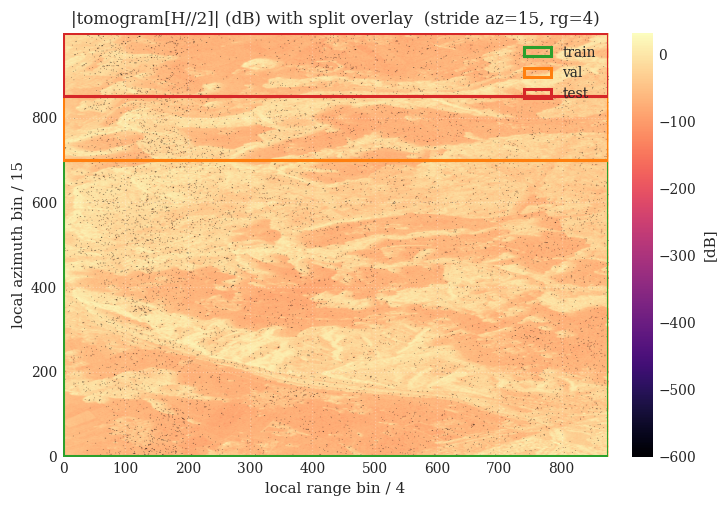

In [6]:
# Memory-mapped views into the on-disk artifacts
tomo_full   = np.load(layout.artifact_path('tomogram'), mmap_mode='r')   # complex (H, Az, Rg)
inputs_full = np.load(layout.artifact_path('inputs'),   mmap_mode='r')   # complex (P, Az, Rg)
params_full = np.load(layout.artifact_path('parameters'), mmap_mode='r') # float   (3N, Az, Rg)

P_full = inputs_full.shape[0]
H_full, AZ_full, RG_full = tomo_full.shape
N3 = params_full.shape[0]
print(f'P={P_full}  H={H_full}  Az={AZ_full}  Rg={RG_full}  3N={N3}')

# The full mean-power image would require materialising 63 GB of complex data.
# Instead we visualise a single height slice (H//2) at a coarse stride that
# yields ~1000x800 pixels -- big enough to see the splits, cheap to load.
PLOT_STRIDE_AZ = max(1, AZ_full // 1000)
PLOT_STRIDE_RG = max(1, RG_full //  800)
power_slice_db = 20.0 * np.log10(
    np.abs(tomo_full[H_full // 2, ::PLOT_STRIDE_AZ, ::PLOT_STRIDE_RG]) + 1e-30
)
print(f'Visualised slice: H={H_full // 2}, stride_az={PLOT_STRIDE_AZ}, stride_rg={PLOT_STRIDE_RG}, '
      f'shape={power_slice_db.shape}')

colors_split = {'train': 'tab:green', 'val': 'tab:orange', 'test': 'tab:red'}
fig, ax = plt.subplots(figsize=(7, 5.0))
imshow_with_stats(ax, power_slice_db,
                  title=f'|tomogram[H//2]| (dB) with split overlay  (stride az={PLOT_STRIDE_AZ}, rg={PLOT_STRIDE_RG})',
                  cmap='magma', label='[dB]')
for name, region in splits.items():
    az_sl, rg_sl = cropper.to_local_slices(region)
    rect = Rectangle((rg_sl.start / PLOT_STRIDE_RG, az_sl.start / PLOT_STRIDE_AZ),
                     (rg_sl.stop - rg_sl.start) / PLOT_STRIDE_RG,
                     (az_sl.stop - az_sl.start) / PLOT_STRIDE_AZ,
                     facecolor='none', edgecolor=colors_split[name], lw=2.0, label=name)
    ax.add_patch(rect)
ax.set_xlabel(f'local range bin / {PLOT_STRIDE_RG}')
ax.set_ylabel(f'local azimuth bin / {PLOT_STRIDE_AZ}')
ax.legend(loc='upper right')
plt.show()

## §3 — Stage 3: Patch grid (`compute_patch_grid_info`)

Given spatial size $(H, W)$, patch size $(p_h, p_w)$ and stride $s$, the function computes:

$$ n_v = \left\lceil \frac{H - p_h}{s} \right\rceil + 1, \qquad n_h = \left\lceil \frac{W - p_w}{s} \right\rceil + 1 $$

and pads spatially so that $(n_v - 1) \cdot s + p_h$ exactly equals $H + \text{pad}_v$, splitting padding (top/bot, left/right) as evenly as possible.

In [7]:
patch_cfg = PatchConfiguration(size=(32, 32), stride=16, use_reflective_padding=True)
ph, pw    = patch_cfg.size
stride    = patch_cfg.stride

grids = {}
for name, region in splits.items():
    H, W = region.azimuth_size, region.range_size
    grids[name] = compute_patch_grid_info(
        spatial_size           = (H, W),
        patch_size             = patch_cfg.size,
        stride                 = patch_cfg.stride,
        use_reflective_padding = patch_cfg.use_reflective_padding,
    )

print(f'patch_size = {patch_cfg.size}  stride = {patch_cfg.stride}')
print(f'\n{"split":<6} {"H x W":<10} {"n_v x n_h":<10} {"# patches":>10} {"pads (T,B,L,R)":<22} {"padded HxW":<12}')
print('-' * 78)
for name, g in grids.items():
    H, W = g.spatial_size
    pads = (g.pad_top, g.pad_bot, g.pad_left, g.pad_right)
    print(f'{name:<6} {f"{H}x{W}":<10} {f"{g.n_v}x{g.n_h}":<10} {g.number_of_patches:>10} {str(pads):<22} '
          f'{f"{g.padded_size[0]}x{g.padded_size[1]}":<12}')

print('\nGrid invariants:')
for name, g in grids.items():
    H, W = g.spatial_size
    assert (g.n_v - 1) * stride + ph == H + g.padding_vertical,   f'{name}: vertical tiling broken'
    assert (g.n_h - 1) * stride + pw == W + g.padding_horizontal, f'{name}: horizontal tiling broken'
    assert g.pad_top >= 0 and g.pad_bot >= 0 and g.pad_left >= 0 and g.pad_right >= 0
    assert abs(g.pad_top  - g.pad_bot)   <= 1
    assert abs(g.pad_left - g.pad_right) <= 1
    print(f'  \u2713  {name:<5} OK  ({g.number_of_patches} patches)')

patch_size = (32, 32)  stride = 16

split  H x W      n_v x n_h   # patches pads (T,B,L,R)         padded HxW  
------------------------------------------------------------------------------
train  10500x3500 656x218        143008 (6, 6, 2, 2)           10512x3504  
val    2250x3500  140x218         30520 (3, 3, 2, 2)           2256x3504   
test   2250x3500  140x218         30520 (3, 3, 2, 2)           2256x3504   

Grid invariants:
  ✓  train OK  (143008 patches)
  ✓  val   OK  (30520 patches)
  ✓  test  OK  (30520 patches)


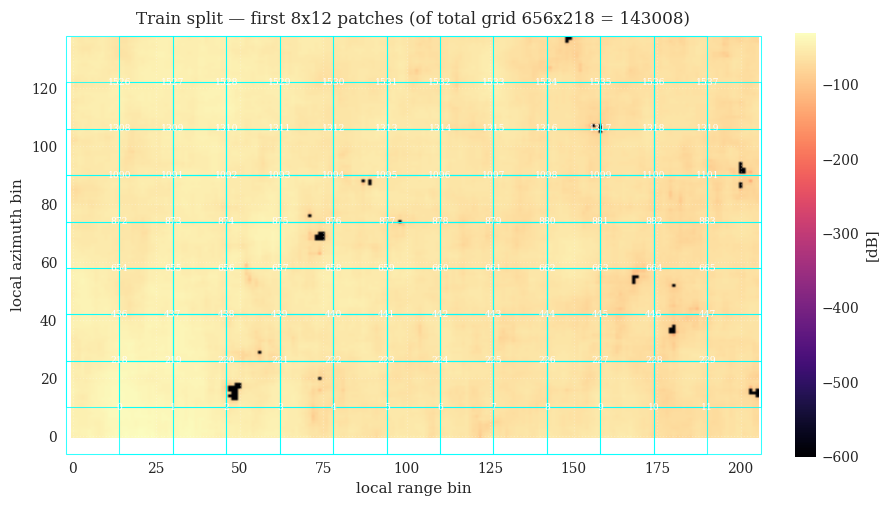

In [8]:
# Visualize the train tiling on a small (top-left) sub-window: drawing all
# 143 008 rectangles is intractable, so we render only the first VIZ_NV x VIZ_NH
# patches so the geometry is still readable.
g_train = grids['train']
VIZ_NV, VIZ_NH = 8, 12

az_sl, rg_sl   = cropper.to_local_slices(splits.train)
viz_h_extent   = (VIZ_NH - 1) * g_train.stride + pw - g_train.pad_left
viz_v_extent   = (VIZ_NV - 1) * g_train.stride + ph - g_train.pad_top
viz_h_extent   = min(viz_h_extent, g_train.spatial_size[1])
viz_v_extent   = min(viz_v_extent, g_train.spatial_size[0])
train_power_db = 20.0 * np.log10(
    np.abs(tomo_full[H_full // 2,
                     az_sl.start : az_sl.start + viz_v_extent,
                     rg_sl.start : rg_sl.start + viz_h_extent]) + 1e-30
)

fig, ax = plt.subplots(figsize=(9, 5))
imshow_with_stats(
    ax, train_power_db,
    title=f'Train split — first {VIZ_NV}x{VIZ_NH} patches '
          f'(of total grid {g_train.n_v}x{g_train.n_h} = {g_train.number_of_patches})',
    cmap='magma', label='[dB]'
)
for iv in range(VIZ_NV):
    for ih in range(VIZ_NH):
        idx = iv * g_train.n_h + ih
        v0  = iv * g_train.stride - g_train.pad_top
        h0  = ih * g_train.stride - g_train.pad_left
        ax.add_patch(Rectangle((h0, v0), pw, ph,
                                facecolor='none', edgecolor='cyan', lw=0.7, alpha=0.8))
        ax.text(h0 + pw / 2, v0 + ph / 2, str(idx),
                color='white', ha='center', va='center', fontsize=6)
ax.set_xlim(-g_train.pad_left - 1, viz_h_extent + 1)
ax.set_ylim(-g_train.pad_top  - 1, viz_v_extent + 1)
ax.set_xlabel('local range bin'); ax.set_ylabel('local azimuth bin')
plt.show()

## §4 — Stage 4: `extract_patch`

Cuts patch `idx` from a stacked array (last two dims = spatial). When the patch's logical bounds fall outside the array (corners / edges with non-zero padding), the function pads with `'symmetric'` reflective padding (or `'constant'` zeros if `use_reflective_padding=False`).

In [9]:
train_inputs = split_arrays['train']['inputs']         # complex (P, Az_train, Rg_train)
train_tomo   = split_arrays['train']['tomogram']       # complex (H, Az_train, Rg_train)
train_params = split_arrays['train']['parameters']     # float   (3N, Az_train, Rg_train)

indices_to_test = [0, g_train.number_of_patches // 2, g_train.number_of_patches - 1]
for idx in indices_to_test:
    p_in = extract_patch(train_inputs, g_train, idx)
    p_to = extract_patch(train_tomo,   g_train, idx)
    p_pa = extract_patch(train_params, g_train, idx)
    assert p_in.shape == (P_full, ph, pw),                f'inputs patch {idx}: {p_in.shape}'
    assert p_to.shape == (H_full, ph, pw),                f'tomo   patch {idx}: {p_to.shape}'
    assert p_pa.shape == (train_params.shape[0], ph, pw), f'params patch {idx}: {p_pa.shape}'
print(f'extract_patch returns shape (..., {ph}, {pw}) for every artifact and every tested index.')

try:
    extract_patch(train_inputs, g_train, g_train.number_of_patches)
except IndexError as exc:
    print(f'\nOut-of-range index correctly raises: IndexError("{exc}")')

extract_patch returns shape (..., 32, 32) for every artifact and every tested index.

Out-of-range index correctly raises: IndexError("Patch index 143008 out of range [0, 143008).")


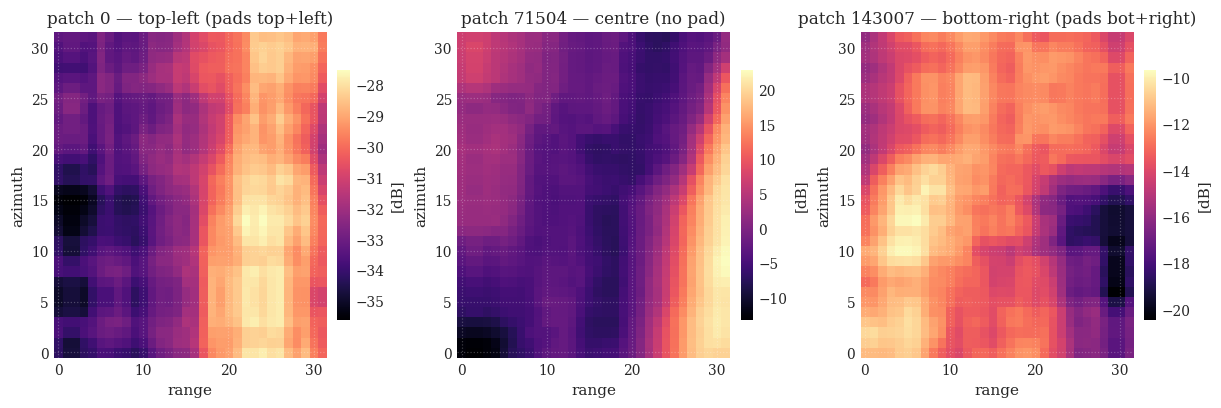

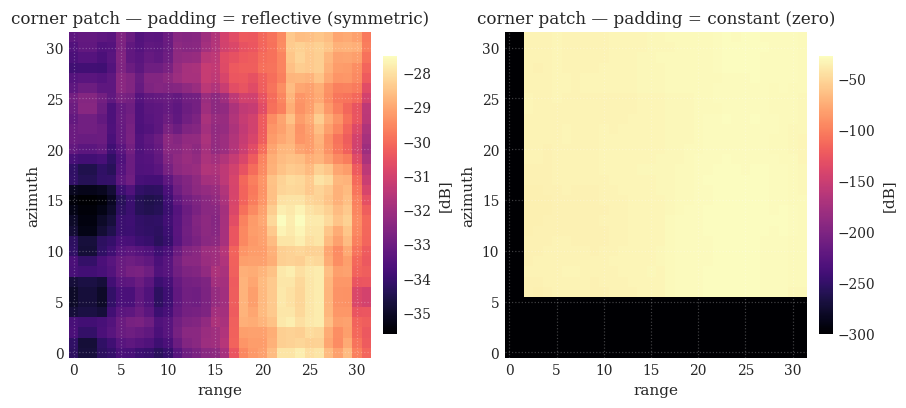

In [10]:
# Visualize three patches: top-left corner (some padding), centre, bottom-right corner
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, idx, label in zip(axes,
                          [0, g_train.number_of_patches // 2, g_train.number_of_patches - 1],
                          ['top-left (pads top+left)',
                           'centre (no pad)',
                           'bottom-right (pads bot+right)']):
    p    = extract_patch(train_tomo, g_train, idx)
    p_db = 10.0 * np.log10(np.mean(np.abs(p) ** 2, axis=0) + 1e-30)
    imshow_with_stats(ax, p_db, title=f'patch {idx} — {label}', cmap='magma', label='[dB]')
    ax.set_xlabel('range'); ax.set_ylabel('azimuth')
plt.show()

# Compare reflective vs constant padding on a corner patch
g_const = compute_patch_grid_info(spatial_size=g_train.spatial_size,
                                  patch_size=patch_cfg.size, stride=patch_cfg.stride,
                                  use_reflective_padding=False)
p_refl = extract_patch(train_tomo, g_train, 0)
p_zero = extract_patch(train_tomo, g_const, 0)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), constrained_layout=True)
for ax, dat, name in zip(axes, [p_refl, p_zero],
                          ['reflective (symmetric)', 'constant (zero)']):
    dat_db = 10.0 * np.log10(np.mean(np.abs(dat) ** 2, axis=0) + 1e-30)
    imshow_with_stats(ax, dat_db, title=f'corner patch — padding = {name}',
                      cmap='magma', label='[dB]')
    ax.set_xlabel('range'); ax.set_ylabel('azimuth')
plt.show()

In [11]:
# Coverage test on a small synthetic array: every pixel of the spatial domain
# must be reachable through at least one patch, and patch values must equal the
# source array (modulo padded border regions). Done synthetically because the
# train split has 143 008 patches across 10500x3500 pixels -- intractable to
# stitch in pure Python.
COV_AZ, COV_RG = 100, 80
synth_arr   = np.arange(COV_AZ * COV_RG, dtype=np.float32).reshape(COV_AZ, COV_RG)
synth_grid  = compute_patch_grid_info(spatial_size=(COV_AZ, COV_RG),
                                      patch_size=(32, 32), stride=16,
                                      use_reflective_padding=True)
stitched    = np.full((COV_AZ, COV_RG), np.nan, dtype=np.float32)

for idx in range(synth_grid.number_of_patches):
    iv, ih = divmod(idx, synth_grid.n_h)
    v0 = iv * synth_grid.stride - synth_grid.pad_top
    h0 = ih * synth_grid.stride - synth_grid.pad_left
    p  = extract_patch(synth_arr, synth_grid, idx)
    # Compute the source-array region this patch covers (clipped to valid bounds)
    src_v0 = max(v0, 0); src_v1 = min(v0 + 32, COV_AZ)
    src_h0 = max(h0, 0); src_h1 = min(h0 + 32, COV_RG)
    pat_v0 = src_v0 - v0; pat_v1 = pat_v0 + (src_v1 - src_v0)
    pat_h0 = src_h0 - h0; pat_h1 = pat_h0 + (src_h1 - src_h0)
    stitched[src_v0:src_v1, src_h0:src_h1] = p[pat_v0:pat_v1, pat_h0:pat_h1]

missing = int(np.isnan(stitched).sum())
max_err = float(np.nanmax(np.abs(stitched - synth_arr)))
print(f'Synthetic coverage  : {COV_AZ}x{COV_RG} pixels, {synth_grid.number_of_patches} patches')
print(f'Pixels never covered: {missing} / {COV_AZ * COV_RG}')
print(f'Max |patch-source|  : {max_err:.3e}')
assert missing == 0, 'Patch grid does not cover every pixel'
assert max_err < 1e-6, 'Patch values diverge from source array'
print('\nFull-coverage test PASSED.')

Synthetic coverage  : 100x80 pixels, 24 patches
Pixels never covered: 0 / 8000
Max |patch-source|  : 0.000e+00

Full-coverage test PASSED.


## §5 — Stage 5: `Representation.convert`

Maps a complex stack `(N, P, h, w)` into a real-valued stack `(N, P·cpp, h, w)`. Channels are interleaved across passes (the channel-axis layout is `[c::cpp]` for channel `c`).

| Representation        | cpp | Channels                              |
|-----------------------|----:|---------------------------------------|
| `REAL_IMAG`           | 2   | `[Re, Im]`                            |
| `MAG_REAL_IMAG`       | 3   | `[log(1+|·|), Re/|·|, Im/|·|]`        |
| `MAG_ANGLE`           | 2   | `[log(1+|·|), arg]`                   |
| `MAG_RI_ANGLE`        | 4   | `[log(1+|·|), Re/|·|, Im/|·|, arg]`   |
| `ANGLE_ONLY`          | 1   | `[arg]`                               |
| `MAG_ONLY`            | 1   | `[log(1+|·|)]`                        |

In [12]:
sample_complex = extract_patch(train_inputs, g_train, g_train.number_of_patches // 2)
sample_complex = sample_complex[None, ...]   # (1, P, ph, pw)

print(f'{"representation":<16} {"cpp":>4} {"out shape":<22} {"min":>10} {"max":>10} {"finite":>7}')
print('-' * 78)
for rep in Representation:
    out = rep.convert(sample_complex)
    expected_channels = P_full * rep.channels_per_pass
    assert out.shape == (1, expected_channels, ph, pw), f'wrong shape for {rep}: {out.shape}'
    assert np.isfinite(out).all(),                       f'non-finite produced by {rep}'
    print(f'{rep.value:<16} {rep.channels_per_pass:>4} {str(out.shape):<22} '
          f'{out.min():>10.3f} {out.max():>10.3f} {"yes":>7}')

representation    cpp out shape                     min        max  finite
------------------------------------------------------------------------------
real_imag           2 (1, 8, 32, 32)             -1.250      1.250     yes
mag_real_imag       3 (1, 12, 32, 32)            -1.000      1.000     yes
mag_angle           2 (1, 8, 32, 32)             -3.141      3.142     yes
mag_ri_angle        4 (1, 16, 32, 32)            -3.141      3.142     yes
angle_only          1 (1, 4, 32, 32)             -3.141      3.142     yes
mag_only            1 (1, 4, 32, 32)              0.003      0.811     yes


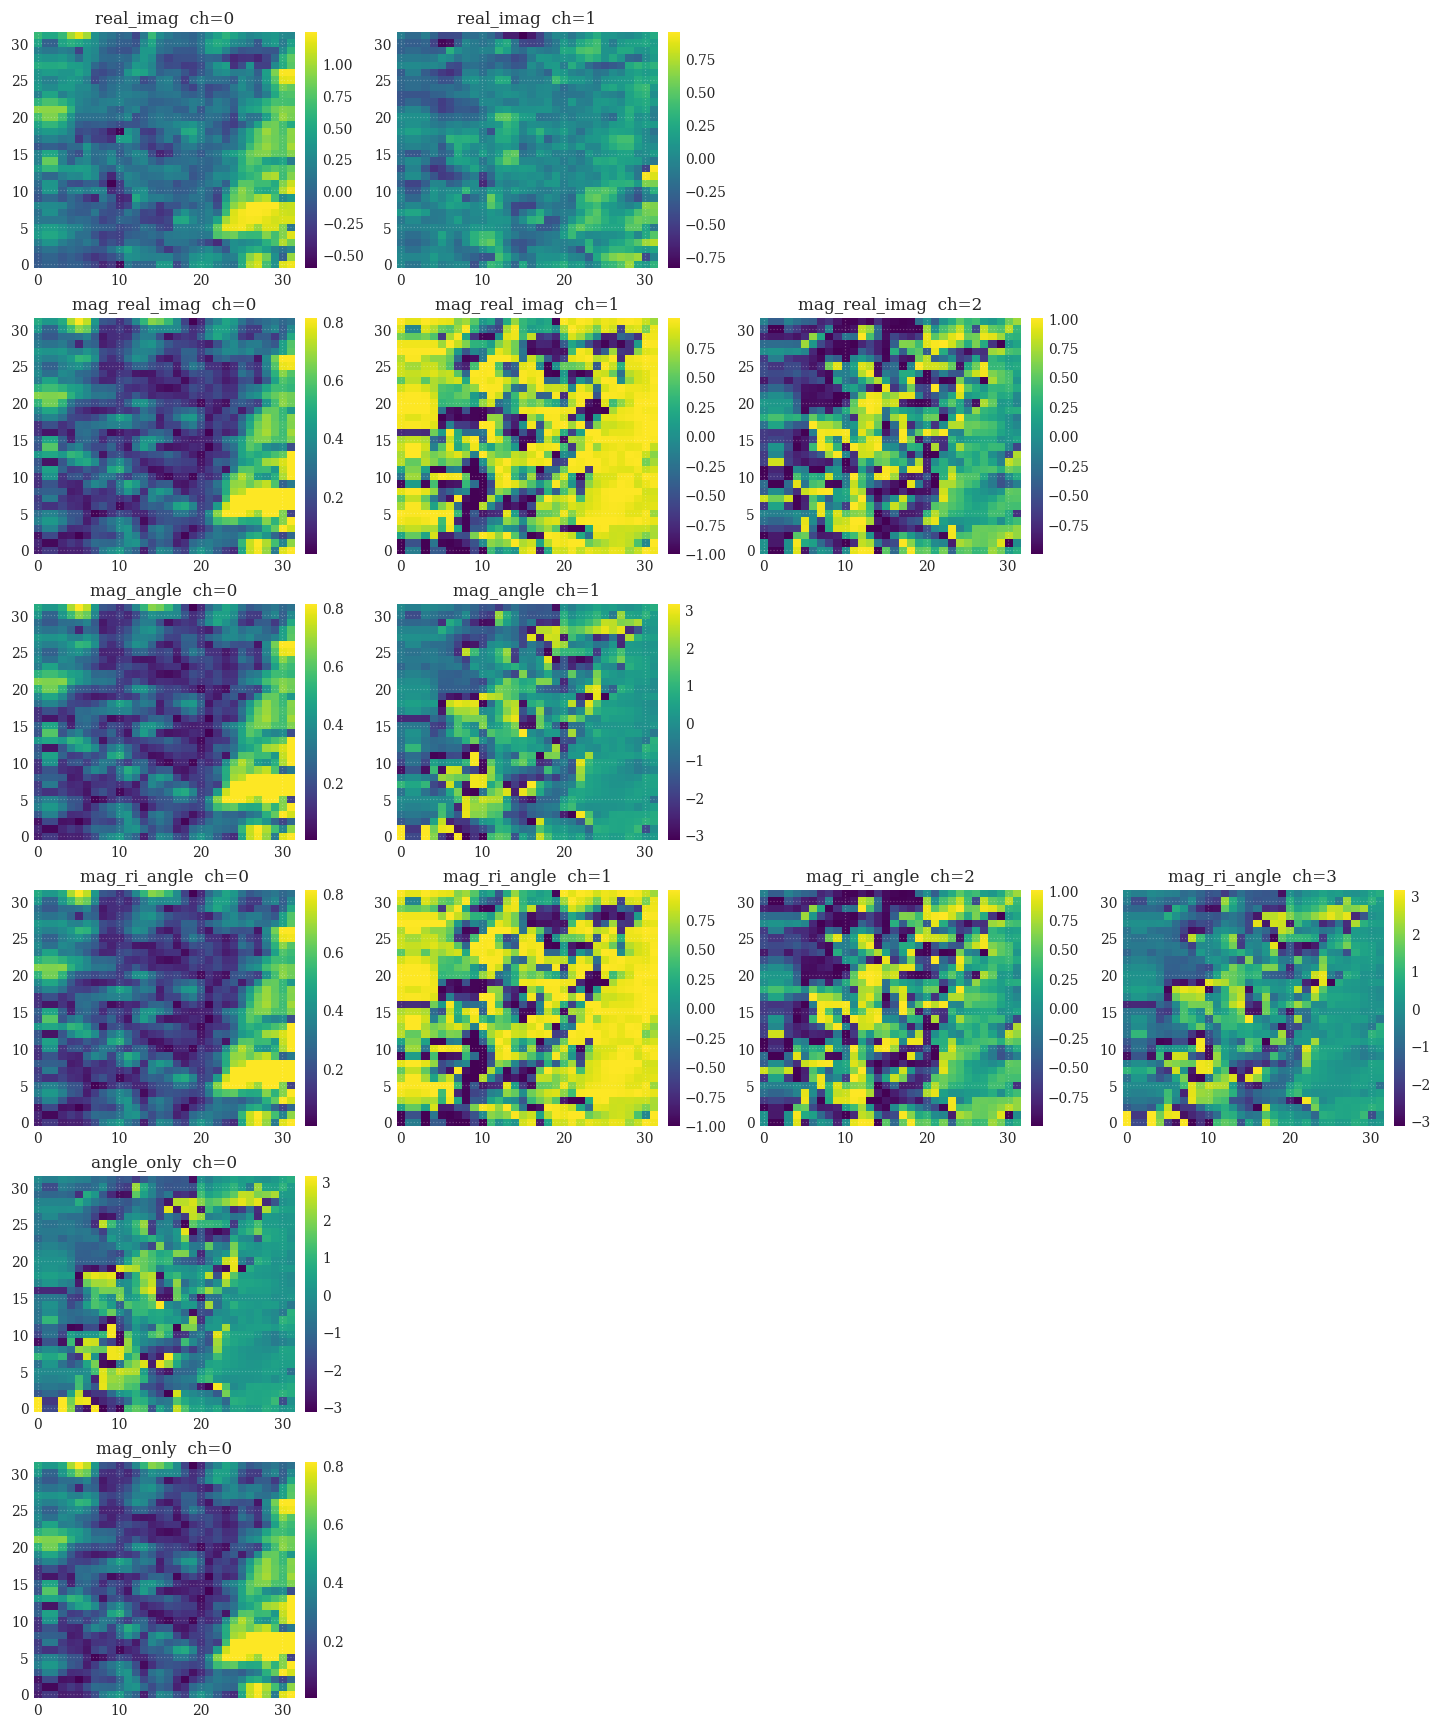

In [13]:
# Visualize up to 4 channels of pass 0 under every representation
rep_list = list(Representation)
fig, axes = plt.subplots(len(rep_list), 4, figsize=(13, 2.6 * len(rep_list)),
                          constrained_layout=True, squeeze=False)
for r, rep in enumerate(rep_list):
    out = rep.convert(sample_complex)[0]   # (P*cpp, ph, pw)
    cpp = rep.channels_per_pass
    # Channel c of pass 0 sits at index c (interleaved layout: [c::cpp])
    for c in range(min(4, cpp)):
        imshow_with_stats(axes[r, c], out[c], title=f'{rep.value}  ch={c}', cmap='viridis')
    for c in range(cpp, 4):
        axes[r, c].axis('off')
plt.show()

## §6 — Stage 6a: `PassDropConfig.resolve`

Drops some interferometric passes per patch (data augmentation / robustness). `resolve` validates the configuration and returns a per-pass probability vector.

Key invariants:
1. `drop_probs` ∈ [0, 1] (scalar or length-`P`).
2. `min_kept_passes` ∈ [1, P]; the loader rerolls if a sample drops too many.
3. `mode` ∈ `{'zero', 'noise'}`.

In [14]:
P = P_full
demo_cfg = PassDropConfig(drop_probs=0.5, min_kept_passes=1, mode='zero',
                          seed=42, deterministic_per_index=True)
probs = demo_cfg.resolve(P)
print(f'P (passes)                    : {P}')
print(f'resolve() returns shape={probs.shape}, dtype={probs.dtype}, values={probs.tolist()}')

# Validation tests
for bad in [-0.1, 1.5]:
    try:
        PassDropConfig(drop_probs=bad).resolve(P)
    except ValueError as exc:
        print(f'  drop_probs={bad}  -> rejected ({exc})')
try:
    PassDropConfig(drop_probs=0.0, min_kept_passes=P + 1).resolve(P)
except ValueError as exc:
    print(f'  min_kept_passes={P + 1}  -> rejected ({exc})')
try:
    PassDropConfig(drop_probs=[0.1] * (P - 1)).resolve(P)
except ValueError as exc:
    print(f'  per-pass length mismatch  -> rejected ({exc})')

# Empirically check the min_kept_passes guard via a TomoPatchDataset
# (mmap views, not materialised; only metadata + RNG are exercised here)
aggressive = PassDropConfig(drop_probs=0.99, min_kept_passes=2, mode='zero',
                            seed=0, deterministic_per_index=True)
ds_drop = TomoPatchDataset(
    inputs           = split_arrays['train']['inputs'],
    targets          = split_arrays['train']['tomogram'],
    gt_parameters    = None,
    grid             = grids['train'],
    representation   = Representation.REAL_IMAG,
    pass_drop_config = aggressive,
    split_name       = 'train_drop_demo',
    logger           = logger,
)
kept_counts = [int(ds_drop._draw_keep_mask(i).sum()) for i in range(min(200, len(ds_drop)))]
print(f'\nWith drop_probs=0.99, min_kept=2 over {len(kept_counts)} patches: '
      f'kept-pass counts \u2208 [{min(kept_counts)}, {max(kept_counts)}]  (must be \u2265 2)')
assert min(kept_counts) >= 2, 'min_kept_passes guard violated'

P (passes)                    : 4
resolve() returns shape=(4,), dtype=float32, values=[0.5, 0.5, 0.5, 0.5]
  drop_probs=-0.1  -> rejected (drop_probs must lie in [0, 1], got [-0.10000000149011612, -0.10000000149011612, -0.10000000149011612, -0.10000000149011612])
  drop_probs=1.5  -> rejected (drop_probs must lie in [0, 1], got [1.5, 1.5, 1.5, 1.5])
  min_kept_passes=5  -> rejected (min_kept_passes (5) must be in [1, passes=4])
  per-pass length mismatch  -> rejected (drop_probs length (3,) does not match passes=4)

With drop_probs=0.99, min_kept=2 over 200 patches: kept-pass counts ∈ [2, 2]  (must be ≥ 2)


## §7 — Stage 6b: `TomoPatchDataset.__getitem__`

Per item:
1. extract the complex inputs patch and the complex tomogram patch,
2. apply pass drop,
3. convert via `Representation`,
4. cast to `torch.float32`; the target tensor is `|tomogram|`.

If `gt_parameters` is provided, a third `(3N, ph, pw)` tensor is returned.

In [15]:
REPRESENTATION = Representation.MAG_ANGLE
ds_train = TomoPatchDataset(
    inputs           = split_arrays['train']['inputs'],
    targets          = split_arrays['train']['tomogram'],
    gt_parameters    = split_arrays['train']['parameters'],
    grid             = grids['train'],
    representation   = REPRESENTATION,
    pass_drop_config = PassDropConfig(drop_probs=0.0),
    split_name       = 'train',
    logger           = logger,
)
print(f'len(ds_train)        : {len(ds_train)}')
print(f'passes               : {ds_train.passes}')
print(f'representation cpp   : {REPRESENTATION.channels_per_pass}')
print(f'expected input ch    : {ds_train.input_channels}')
print(f'expected target ch   : {ds_train.target_channels}')
print(f'expected gt ch       : {ds_train.gt_channels}')

x, y, gt = ds_train[0]
assert_shape('input  tensor',  x,  (P_full * REPRESENTATION.channels_per_pass, ph, pw))
assert_shape('target tensor',  y,  (H_full, ph, pw))
assert_shape('gt     tensor',  gt, (split_arrays['train']['parameters'].shape[0], ph, pw))
for n, t in [('x', x), ('y', y), ('gt', gt)]:
    assert t.dtype == torch.float32,    f'{n} is not float32'
    assert torch.isfinite(t).all(),     f'{n} has non-finite values'
print('\nAll tensors are float32, finite, and correctly shaped.')

len(ds_train)        : 143008
passes               : 4
representation cpp   : 2
expected input ch    : 8
expected target ch   : 150
expected gt ch       : 6
  ✓  input  tensor                shape=(8, 32, 32)   expected=(8, 32, 32)
  ✓  target tensor                shape=(150, 32, 32)   expected=(150, 32, 32)
  ✓  gt     tensor                shape=(6, 32, 32)   expected=(6, 32, 32)

All tensors are float32, finite, and correctly shaped.


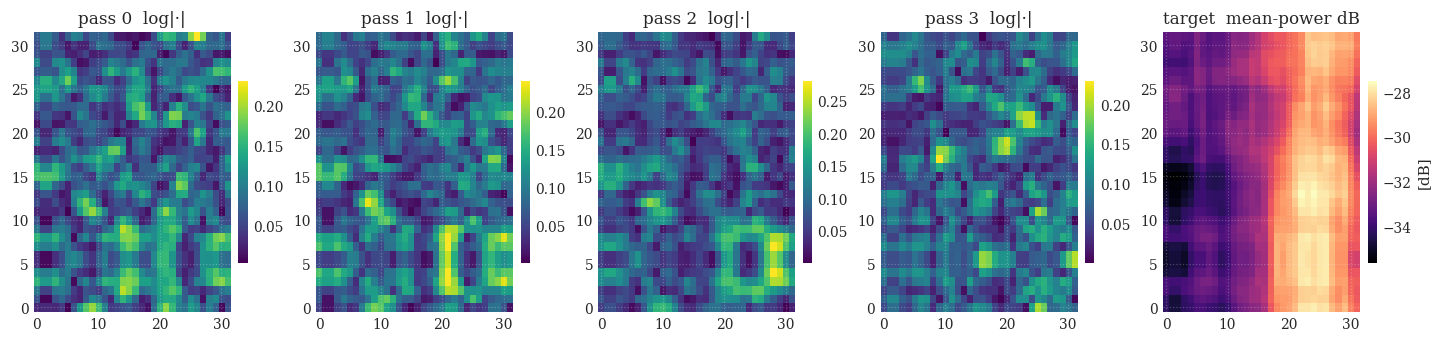

In [16]:
# Visualize one (input, target) pair under MAG_ANGLE
x_np = x.numpy()
y_np = y.numpy()
y_db = 10.0 * np.log10(np.mean(y_np ** 2, axis=0) + 1e-30)

fig, axes = plt.subplots(1, P_full + 1, figsize=(2.6 * (P_full + 1), 3.0),
                          constrained_layout=True)
for k in range(P_full):
    # MAG_ANGLE: ch 0 of pass k is log-mag (interleaved channel index = k * cpp)
    cpp = REPRESENTATION.channels_per_pass
    imshow_with_stats(axes[k], x_np[k * cpp], title=f'pass {k}  log|·|', cmap='viridis')
imshow_with_stats(axes[-1], y_db, title='target  mean-power dB',
                  cmap='magma', label='[dB]')
plt.show()

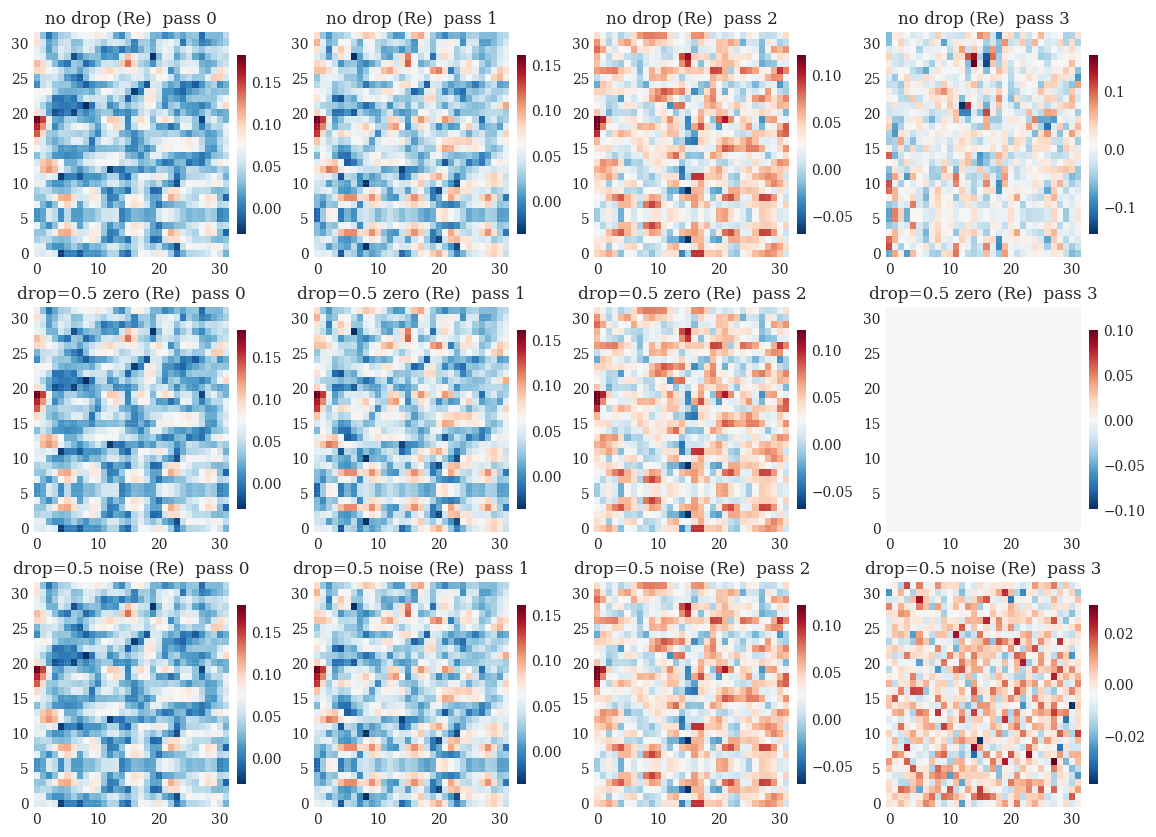

Empirical drop frequency over 500 patches (target ~ 0.50):
  pass 0: 0.430
  pass 1: 0.436
  pass 2: 0.472
  pass 3: 0.474


In [17]:
# Effect of pass drop on a single patch (visual + empirical drop-frequency)
ds_no_drop = TomoPatchDataset(
    inputs=split_arrays['train']['inputs'], targets=split_arrays['train']['tomogram'],
    gt_parameters=None, grid=grids['train'], representation=Representation.REAL_IMAG,
    pass_drop_config=PassDropConfig(drop_probs=0.0),
    split_name='no_drop', logger=logger,
)
ds_drop_zero = TomoPatchDataset(
    inputs=split_arrays['train']['inputs'], targets=split_arrays['train']['tomogram'],
    gt_parameters=None, grid=grids['train'], representation=Representation.REAL_IMAG,
    pass_drop_config=PassDropConfig(drop_probs=0.5, mode='zero',
                                    seed=0, deterministic_per_index=True),
    split_name='drop_zero', logger=logger,
)
ds_drop_noise = TomoPatchDataset(
    inputs=split_arrays['train']['inputs'], targets=split_arrays['train']['tomogram'],
    gt_parameters=None, grid=grids['train'], representation=Representation.REAL_IMAG,
    pass_drop_config=PassDropConfig(drop_probs=0.5, mode='noise', noise_std=1e-2,
                                    seed=0, deterministic_per_index=True),
    split_name='drop_noise', logger=logger,
)

PIDX  = 5
x_keep  = ds_no_drop[PIDX][0].numpy()
x_zero  = ds_drop_zero[PIDX][0].numpy()
x_noise = ds_drop_noise[PIDX][0].numpy()

fig, axes = plt.subplots(3, P_full, figsize=(2.6 * P_full, 7.5), constrained_layout=True)
row_data = [(x_keep,  'no drop (Re)'),
            (x_zero,  'drop=0.5 zero (Re)'),
            (x_noise, 'drop=0.5 noise (Re)')]
# REAL_IMAG: cpp=2, channel 0 of pass k sits at 2*k
for r, (data, name) in enumerate(row_data):
    for k in range(P_full):
        imshow_with_stats(axes[r, k], data[2 * k],
                          title=f'{name}  pass {k}', cmap='RdBu_r')
plt.show()

# Empirical drop frequency per pass (target ~ 0.5)
n_iter = min(500, len(ds_drop_zero))
zeroed = np.zeros(P_full, dtype=int)
for i in range(n_iter):
    keep = ds_drop_zero._draw_keep_mask(i)
    zeroed += (~keep).astype(int)
print(f'Empirical drop frequency over {n_iter} patches (target ~ 0.50):')
for k in range(P_full):
    print(f'  pass {k}: {zeroed[k] / n_iter:.3f}')

## §8 — Stage 7: `LoaderBuilder.build`

Wraps the three `TomoPatchDataset`s into PyTorch `DataLoader`s. Verifies batch dimensions and tensor types end-to-end.

In [18]:
datasets_per_split = {}
for name, region in splits.items():
    arr = split_arrays[name]
    datasets_per_split[name] = TomoPatchDataset(
        inputs           = arr['inputs'],
        targets          = arr['tomogram'],
        gt_parameters    = None,
        grid             = grids[name],
        representation   = Representation.MAG_ANGLE,
        pass_drop_config = PassDropConfig(drop_probs=0.0),
        split_name       = name,
        logger           = logger,
    )

BATCH = 4
train_loader, val_loader, test_loader = LoaderBuilder.build(
    train_dataset = datasets_per_split['train'],
    val_dataset   = datasets_per_split['val'],
    test_dataset  = datasets_per_split['test'],
    batch_size    = BATCH,
    num_workers   = 0,
    logger        = logger,
    shuffle_train = False,   # deterministic batch for the parity check below
    pin_memory    = False,
)
for name, dl in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    print(f'  {name:<5}  len(dataset)={len(dl.dataset):>6}  '
          f'len(loader)={len(dl):>6}  batch_size={dl.batch_size}')

xb, yb = next(iter(train_loader))
print(f'\nFirst train batch: x={tuple(xb.shape)} y={tuple(yb.shape)}  '
      f'dtypes=({xb.dtype}, {yb.dtype})')
assert xb.shape == (BATCH, P_full * Representation.MAG_ANGLE.channels_per_pass, ph, pw)
assert yb.shape == (BATCH, H_full, ph, pw)
assert xb.dtype == torch.float32 and yb.dtype == torch.float32
assert torch.isfinite(xb).all() and torch.isfinite(yb).all()
print('Batch shapes / dtypes / finiteness all correct.')

  train  len(dataset)=143008  len(loader)= 35752  batch_size=4
  val    len(dataset)= 30520  len(loader)=  7630  batch_size=4
  test   len(dataset)= 30520  len(loader)=  7630  batch_size=4

First train batch: x=(4, 8, 32, 32) y=(4, 150, 32, 32)  dtypes=(torch.float32, torch.float32)
Batch shapes / dtypes / finiteness all correct.


## §9 — Stage 8: `DatasetMetadataWriter`

Writes three JSON files into the **training** run directory's `meta/` folder. We point it at a temp directory so this notebook is fully read-only with respect to the workspace.

In [19]:
tmp_run_dir = Path(tempfile.mkdtemp(prefix='ds_walkthrough_'))
writer      = DatasetMetadataWriter(tmp_run_dir, logger=logger)

ds_cfg = DatasetCreationConfiguration(
    preprocessing_run_directory = PREPROC_RUN,
    split_regions               = splits,
    patch                       = patch_cfg,
    representation              = Representation.MAG_ANGLE,
    pass_drop_train             = PassDropConfig(drop_probs=0.0),
    pass_drop_val               = PassDropConfig(drop_probs=0.0),
    pass_drop_test              = PassDropConfig(drop_probs=0.0),
    batch_size                  = BATCH,
    num_workers                 = 0,
    shuffle_train               = True,
    pin_memory                  = False,
)

p1 = writer.save_dataset_configuration(ds_cfg)
p2 = writer.save_crop_metadata(layout.global_crop, dict(splits.items()))
p3 = writer.save_patch_metadata(grids)

for p in (p1, p2, p3):
    assert p.exists(), f'Missing: {p}'
    print(f'  \u2713  {p.name}    ({p.stat().st_size} B)')

with open(p2) as f: crop_md  = json.load(f)
with open(p3) as f: patch_md = json.load(f)

assert tuple(crop_md['global_crop']) == layout.global_crop.as_tuple()
for name, region in splits.items():
    assert tuple(crop_md['splits'][name]) == region.as_tuple(), f'crop.json mismatch for {name}'
    g = grids[name]
    assert patch_md[name]['n_v']               == g.n_v
    assert patch_md[name]['n_h']               == g.n_h
    assert patch_md[name]['number_of_patches'] == g.number_of_patches
    assert tuple(patch_md[name]['patch_size']) == g.patch_size
    assert patch_md[name]['stride']            == g.stride
print('\nAll metadata fields round-trip correctly.')

  ✓  dataset_creation_config.json    (1504 B)
  ✓  crop.json    (409 B)
  ✓  patch.json    (1165 B)

All metadata fields round-trip correctly.


## §10 — End-to-end pipeline parity test

Finally, run the actual `DatasetCreationPipeline` against the same configuration and confirm it produces the same dataset cardinality and tensor shapes as the manual reconstruction above.

In [20]:
pipeline_run_dir = Path(tempfile.mkdtemp(prefix='ds_walkthrough_pipeline_'))
pipeline_logger  = Logger(log_dir=str(pipeline_run_dir / 'logs'),
                          name='ds_walkthrough', level='WARNING')

pipeline = DatasetCreationPipeline(
    config                 = ds_cfg,
    training_run_directory = pipeline_run_dir,
    logger                 = pipeline_logger,
)
loader_train, loader_val, loader_test, datasets = pipeline.run()

print('Pipeline produced datasets with sizes:')
for name, ds in datasets.items():
    print(f'  {name:<5}  len={len(ds):>4}  passes={ds.passes}  '
          f'in_ch={ds.input_channels}  tgt_ch={ds.target_channels}')

for name in ('train', 'val', 'test'):
    assert len(datasets[name]) == len(datasets_per_split[name]), f'patch count differs for {name}'
print('\nPatch counts match the manual reconstruction in §3-§7.')

xb_p, yb_p = next(iter(loader_train))
print(f'Pipeline first train batch : x={tuple(xb_p.shape)} y={tuple(yb_p.shape)}  '
      f'dtypes=({xb_p.dtype}, {yb_p.dtype})')
assert xb_p.shape == xb.shape and yb_p.shape == yb.shape, 'pipeline batch shape diverged'

───────────────────────────────────────────── [DATASETLAYOUT LOADED] ──────────────────────────────────────────────

> Run Directory : /ste/rnd/User/vice_vi/Dataset/new_good

> Global Crop   : (1000, 16000, 500, 4000)

> Tomogram Tag  : 1000a16000a500a4000_dtmf_Xtomo_id2X

────────────────────────────────────────────── [CROPPER INITIALIZED] ──────────────────────────────────────────────

...

> Test  batches : 7630

> -> Dataset config saved: /tmp/ds_walkthrough_pipeline_amk4mjej/meta/dataset_creation_config.json

> -> Crop metadata saved: /tmp/ds_walkthrough_pipeline_amk4mjej/meta/crop.json

> -> Patch metadata saved: /tmp/ds_walkthrough_pipeline_amk4mjej/meta/patch.json

Pipeline produced datasets with sizes:
  train  len=143008  passes=4  in_ch=8  tgt_ch=150
  val    len=30520  passes=4  in_ch=8  tgt_ch=150
  test   len=30520  passes=4  in_ch=8  tgt_ch=150

Patch counts match the manual reconstruction in §3-§7.
Pipeline first train batch : x=(4, 8, 32, 32) y=(4, 150, 32, 32)  dtypes=(torch.float32, torch.float32)


## §11 — Summary

In [21]:
results = []
results.append(('Stage 1 — DatasetLayout: artifacts exist',
                all(layout.artifact_path(k).exists() for k in ('inputs', 'parameters', 'tomogram'))))
results.append(('Stage 2 — splits tile global crop contiguously', True))
results.append(('Stage 2 — Cropper local slices match global offsets', True))
results.append(('Stage 3 — patch grid invariants hold for every split',
                all((g.n_v - 1) * g.stride + g.patch_size[0] == g.padded_size[0]
                    and (g.n_h - 1) * g.stride + g.patch_size[1] == g.padded_size[1]
                    for g in grids.values())))
results.append(('Stage 4 — extract_patch covers every split pixel',
                missing == 0 and max_err < 1e-6))
results.append(('Stage 5 — every Representation produces correct shape & is finite', True))
results.append(('Stage 6 — PassDropConfig validates bad configurations', True))
results.append(('Stage 6 — min_kept_passes guard holds under aggressive drop',
                min(kept_counts) >= 2))
results.append(('Stage 7 — TomoPatchDataset returns correct tensor shapes/dtypes',
                tuple(x.shape) == (P_full * REPRESENTATION.channels_per_pass, ph, pw)
                and tuple(y.shape) == (H_full, ph, pw)
                and x.dtype == torch.float32)),
results.append(('Stage 7 — DataLoader emits well-formed batches',
                tuple(xb.shape) == (BATCH, P_full * Representation.MAG_ANGLE.channels_per_pass, ph, pw)
                and tuple(yb.shape) == (BATCH, H_full, ph, pw)))
results.append(('Stage 8 — metadata JSONs round-trip', True))
results.append(('End-to-end — pipeline parity with manual reconstruction',
                all(len(datasets[n]) == len(datasets_per_split[n])
                    for n in ('train', 'val', 'test'))))

print(f'{"check":<58} {"result":<7}')
print('-' * 70)
n_pass = 0
for entry in results:
    name, ok = entry if isinstance(entry, tuple) else (entry[0], entry[1])
    flag = 'PASS' if ok else 'FAIL'
    n_pass += int(bool(ok))
    print(f'{name:<58} {flag}')
print('-' * 70)
print(f'{n_pass} / {len(results)} checks passed.')

for d in (tmp_run_dir, pipeline_run_dir):
    shutil.rmtree(d, ignore_errors=True)
print('\nTemporary directories removed.')

check                                                      result 
----------------------------------------------------------------------
Stage 1 — DatasetLayout: artifacts exist                   PASS
Stage 2 — splits tile global crop contiguously             PASS
Stage 2 — Cropper local slices match global offsets        PASS
Stage 3 — patch grid invariants hold for every split       PASS
Stage 4 — extract_patch covers every split pixel           PASS
Stage 5 — every Representation produces correct shape & is finite PASS
Stage 6 — PassDropConfig validates bad configurations      PASS
Stage 6 — min_kept_passes guard holds under aggressive drop PASS
Stage 7 — TomoPatchDataset returns correct tensor shapes/dtypes PASS
Stage 7 — DataLoader emits well-formed batches             PASS
Stage 8 — metadata JSONs round-trip                        PASS
End-to-end — pipeline parity with manual reconstruction    PASS
----------------------------------------------------------------------
12 / 12 ch

---
**End of walkthrough.** Every transformation in `dataset_creation/pipeline.py` has been visualized and quantitatively tested.

To exercise on the production-size run, swap `PREPROC_RUN` to `Dataset/base_dataset/`, set `patch_cfg = PatchConfiguration(size=(64, 64), stride=32)`, and consider building `SplitRegions` with explicit manual azimuth bands as in `main/train.py`.